<a href="https://colab.research.google.com/github/tovagabrielsson-arch/cb2330-project/blob/main/Different_approach_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Gut Microbia from Twins Discordant for Obesity Modulate Metabolism in Mice

##The Paper
The paper reports a study on four adult female twin pairs, where one is lean, and the other obese. Microbiota from each twin was transplaned into adult germ-free mice. The study monitored the changes in fat mass and body composition in mice. Furthermore, the study examined the effects of diet, as well as cohousing mice that recieved discordant microbiota.

The study found that mice receiving microbiota from an obese twin gained more fat mass than mice that recieved microbiota from a lean twin.

However, cohousing mice with lean and obese microbiota could prevent the increase in fat mass in the mice with obese microbiota, when their microbiota was transformed to the microbia's metabolic profile similar to the lean mice. This effect was only observed in mice recieving a diet representing the healthiest tertile the U.S.      



####Notes on the method
The microbiota was profiled using 16S ribosomal RNA profiling, shotgun sequencing, RNA sequencing and mass spectrometry.
Body mass was determined using quantative magnetic resonance.



##The Data Object

Measurements of percentage change in fat mass in mice colonized with gut microbiota from either the lean or obese member of a discordant twin pair. The values used in our model were approximated manually from Figure 1E of the paper at days 8, 15, 22, 29 and 35.

##The Random Variable Chosen
We chose the increase in fat mass after 15 days as our random variable.
This increase is measured in percentage points of change since day 0.

##What the Paper Does
The paper presents the percent change in fat mass and body composition in figures, showing only the mean with error bars for obese and lean mice. There is also a figure showing the % change in fatt mass for one of the twin pairs for five timepoints from day 8 to day 35. They report that according to a two-way ANOVA, there was a significant difference in fat mass (defined as p < 0.05) between mice recieving lean vs obese microbiota.

The paper also reports on the specific bacteria found in each of the mice's microbiota, as well as how the bacterial cultures changed after cohousing, and with different diets.

##The Generative Model
We model fat mass change as the accumulation of daily changes. Each mouse experiences a random daily fluctuation with normal ditribution.

For mice colonized with microbiota from a lean twin, the change per day is simply the normally distributed variable. For the mice colonized with microbiota from an obese twin, the change per day is the normally distributed variable, plus the additional variable theta.


##Parameters and Assumptions
####Our key parameters are:

**Sigma**: The standard deviation of change in fat mass between mice, since not all mice react the same way. We set this parameter to 0.5

**Theta**: The extra daily fat mass gain that the mice get due to the obese microbiota. This was chosen from the figure in the paper, as 10/15. This is a very approximative value due to our lack of raw data.

**V0**: This parameter was chosen as 0.0 to represent the baseline of average weight gain per day for lean mice being 0%.

**Mice**: We simulated the body fat change in 1 000 mice.

**Day**: We chose to simulate over 15 days, to reflect the study design and figure from the paper.

####The Assumptions:
**Constant weight gain**: We assume that the weight gain effect from the introduced microbiota is constant over time

**Same variability**: The same sigma was used for both groups, assuming that the variability is the same within each group.

**Biological noise and other factors**: We assuma that all of the other factors affecting gain of fat mass is included in our random noise parameter.


**Separate housing and neutral diet**: For this model, we decided to ignore the effect of cohousing and diet, assuming that the mice are housed separately and getting the standard diet of low fat mouse chow.


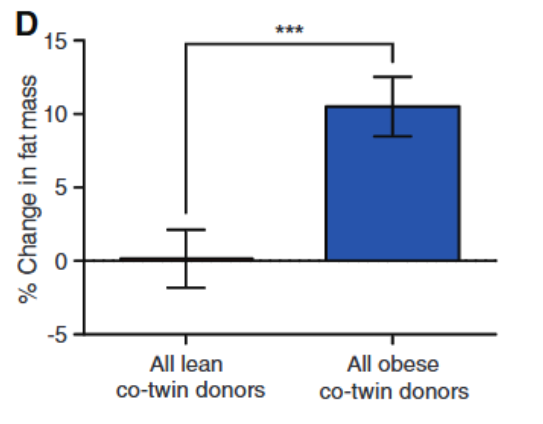

##The Forward Simulation
We simulate 1 000 mice in each group over 15 days.


##The Parametrization
We estimated theta using data from figure 1E in the paper.

##What the model adds to the paper
- Our model adds a quantative parameter, theta, describing the differences between the groups

- The paper follows 4 mice per group, while our model simulated this effect for 1 000 mice per group.

##Model Limitations
Our model is limietd to only reflect the difference in fat mass directly due to microbiota.

The model is very simplified. Our initial forward simulation is based on our assumption of the extra daily fat mass gain being 10/15 for mice recieving microbiota from the obese twin compared to mice recieving microbiota from the lean twin.

Due to the limited data in the paper, the grid seach/ least squares method is based on a very small set of 5 datapoints per type of microbiota. The datapoints are estimated from the figure, not the exact data.


Note that we refer to the mice as "lean" and "obese", allthough the correct interpretation of this should be " the germ-free mice in which microbiota was transplanted from the lean/obese twin"

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bootstrap

# Forward simulation

####Parameters


In [43]:
mice = 1000 #This is the number of mice that we simulate in each group
day = 15 #This is for how long we are running this simulation -> 15 day
v0 = 0.0 #This is our baseline. The report showed that the lean mice on average had a fat mass change of 0% -> therefore it is our starting value
theta = 10/15 #This is the extra daily fat mass gain that the mice get due to the obese microbiota. According to the figure the obese mice gained about 10 percentage points more after 15 days which gives 10/15 per day
sigma = 0.5 #This is added to give some sort of randomness between mice because they don't all react (gain weight equally fast or slow) the same way



####Empty lists
We append and store the final fat mass changes for the lean and fat mice respectivly

In [16]:
lean = [] #Here we create an empty list to which we will append and store the final fat mass changes for the lean mice
obese = [] #Here we create an empty list to which we will append and store the final fat mass changes for the obese mice
theta_boot = [] #Here we create and empty list in which we will store our bootstrap estimates of theta

####Loops to simulate changes in fat mass
We created a loop for lean mice and obese mice separately. The functions loop over our 1 000 mice and our 15 days, assuming normal distribution with the mean 0 and standard deviation 0.5. The loop then adds these values to the lists created above.

In [17]:
for i in range(mice):#We simulate it once for every lean mouse
  fat = 0 #This is our starting fat change according to the figure above
  for j in range(day): #This loop will run as many times as we have days which is 15
    fat = fat + v0 + np.random.normal(0, sigma) #We assume normal distribution. We have assumed that the mean is 0 and the sigma the spread to 0.5 which means that we can generate negative numbers but eh average will be around 0
  lean.append(fat) #We append every final fat change to the lean list -> so every element in the list represents one mouse

for i in range(mice): #We simulate it once for every obese mouse
  fat = 0 #This is our starting fat change according to the figure above
  for j in range(day): #This loop will run as many times as we have days which is 15
    fat = fat + (v0 + theta) + np.random.normal(0, sigma) #We assume normal distribution. We have assumed that the mean is 0 and the sigma the spread to 0.5 which means that we can generate negative numbers but eh average will be around 0. Here we also add the theta term (the extra daily fat mass gain due to the obese microbiota)
  obese.append(fat) #We append every final fat change to the obese list -> so every element in the list represents one mouse


In [18]:
print(f"lean: {lean}") #We print the list which represents the final % fat mass change after 15 days for each and every lean mice
print(f"obese: {obese}") #We print the list which represents the final % fat mass change after 15 days for each and every obese mice

lean: [6.572057372702379, 1.4923372440708662, 0.35624423085620793, -1.9035362693653841, 0.8443560531922353, -0.6077874535850969, 1.7931460801382133, -7.342159776022474, 1.3211652191237953, -1.3157965336929924, 1.5927426163339793, -0.9889831201342264, 0.3797965405278789, -0.5622289213989015, -0.7994904741505373, 3.623784262672496, -1.2259089830901564, -1.2443728061565367, 3.499266716251021, -3.555688774892409, 1.0054179967294175, 0.8786674819192022, 0.6679014645362258, 0.0016320641633760236, -0.3849176649549172, 2.4460715742749377, 2.1810183149752858, -1.9462319465540279, 1.4138451134354466, 2.142033106561919, -2.208942582305345, -0.2941275792354173, -2.0713920533936365, 3.2014419779384515, 0.5982737718253375, 2.1069846281014923, 0.6891079702095824, 5.149923559156689, 0.15898746534482733, 1.8542140448752191, 1.8792707322467974, -0.8260130519708315, -2.7230645109273413, -3.0139233648185764, 0.5698162260196078, -1.3360919115156258, 4.01980795485282, -0.9291094141353331, 2.2162477306752395

In [19]:
mean_lean_mice = np.mean(lean) #Here we calculate the average % fat mass change for the lean mice
mean_obese_mice = np.mean(obese) #Here we calculate the average % fat mass change for the obese mice

print(f"Mean lean: {mean_lean_mice}")
print(f"mean obese: {mean_obese_mice}")

Mean lean: -0.06535622956006235
mean obese: 9.992743293572275


In [20]:
std_lean_mice = np.std(lean) #Here we calculate the standard deviation for the lean mice -> this says how much on average our values differ from the mean
std_obese_mice = np.std(obese) #Here we calculate the standard deviation for the obese mice -> this says how much on average our values differ from the mean

print(f"std lean: {std_lean_mice}")
print(f"std obese: {std_obese_mice}")

std lean: 1.9426975651747842
std obese: 1.9347297003329356


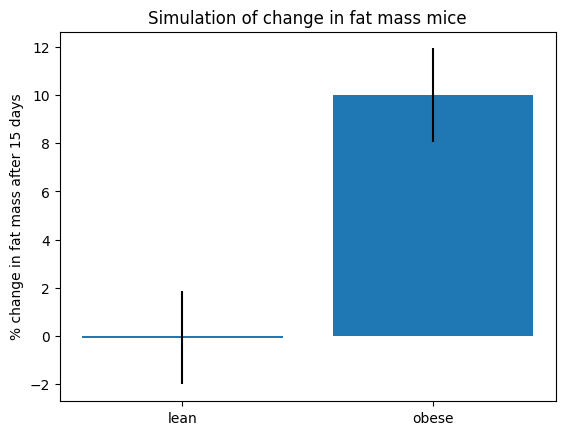

In [21]:
mice_groups = ["lean", "obese"] # we create our two group labels
standard_deviations = [std_lean_mice, std_obese_mice] #Here we take our std, our error bars
mice_means = [mean_lean_mice, mean_obese_mice] #These are the average % fat mass changes
plt.bar(mice_groups, mice_means, yerr=standard_deviations) #Here we plot, where yerr means y-error
plt.ylabel("% change in fat mass after 15 days")
plt.title("Simulation of change in fat mass mice")
plt.show()

# Backward simulation

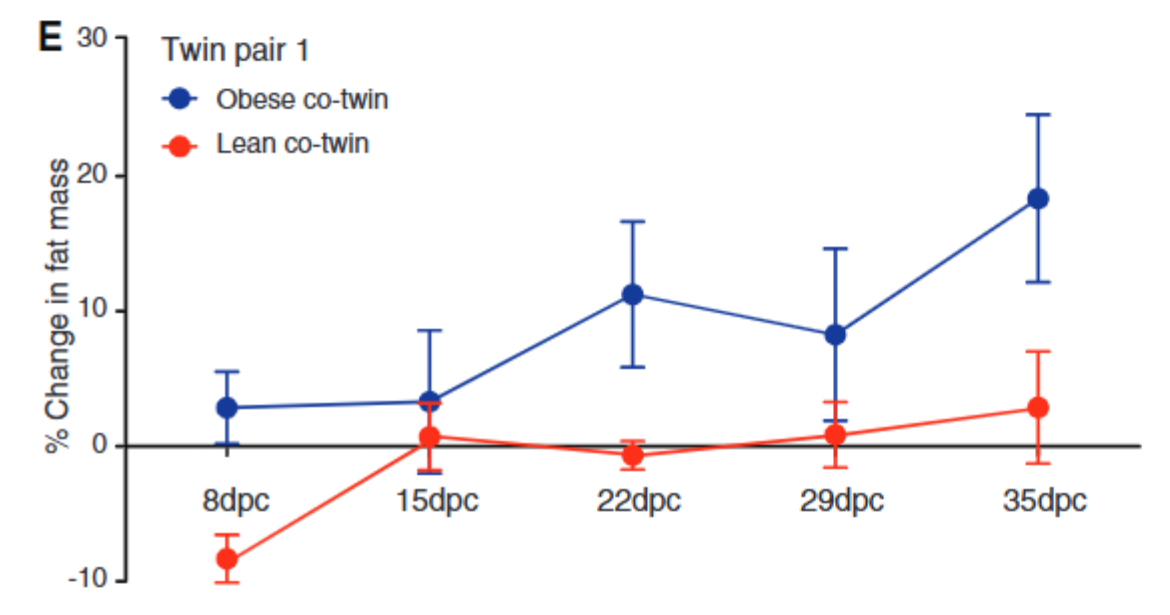

In [22]:
days_report = [8, 15, 22, 29, 35] #The days reported in paper as seen above
lean_report = [-9, 1, -1, 1, 3] #These values were chosen based on the data points for the Lean mice
obese_report = [3, 3, 11, 8, 18] #These values were chosen based on the data points for the Obese mice

####Grid Search
Assuming the adiposity changes with a fixed parameter theta.
We loop through the values etracted from the plot, to find the best theta.

In [28]:
best_theta = 0 #Since we dont have a good value for theta yet our best value is simply zero
smallest_error = 10000 #Any error we calculate should be smaller than this very big number -> could choose any number that is big
errors = [] #This is any empty list -> here we append our error values that we get

for theta in np.linspace(0, 1.5, 1000): #Here we test 1000 different theta values between 0 and 1.5
  error = 0 #We start the error at 0
  for i in range(len(days_report)): #Here we go through the time points that they gave in the report
    predicted_value = theta * days_report[i] #Here we calculate the models predicted value for those days
    error = error + (obese_report[i] - predicted_value)**2 #Here we compare the models predicted value with the reports value and we square it to make sure we have no negative errors
  errors.append(error) #Save current error value into errors list
  if error < smallest_error: #If the theta value gives a smaller error than the previous theta values we save it
    smallest_error = error #We save the new smallest value of theta
    best_theta = theta #We save our corresponding theta value

print(best_theta) #The theta that gave the best fit
print(smallest_error) #This is the corresponding error we get, should be as low as possible

0.41291291291291293
42.3474983993002


####Interpretation
According to our model, the change in fat mass is about 0.413 percentage points per day for the obese mice, with a sum of squared errors at about 42.35. This can indicate that our first approximation of theta, obtained from Figure 1D to 0.6667, was a bit too high.

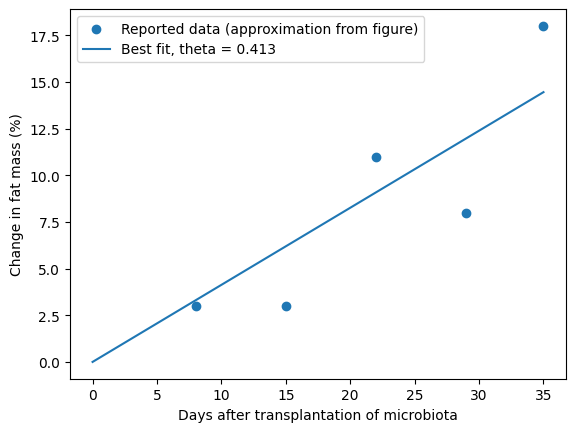

In [29]:
#Here, we plot the model fit
t_plot = np.linspace(0, 35, 200)
model_plot = best_theta * t_plot

plt.scatter(days_report, obese_report, label="Reported data (approximation from figure)")
plt.plot(t_plot, model_plot, label=f"Best fit, theta = {best_theta:.3f}")

plt.xlabel("Days after transplantation of microbiota")
plt.ylabel("Change in fat mass (%)")
plt.legend()
plt.show()

Lägg till Bootstrap för att kolla & plotta osäkerhet?

Best Theta = 0.41291291291291293
95% CI = [0.260747   0.50775416]


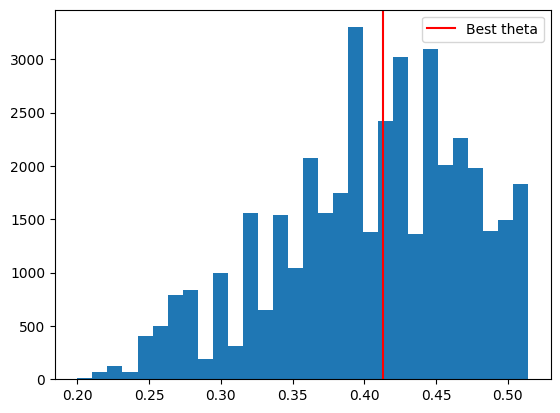

In [47]:
days_report = np.array([8, 15, 22, 29, 35]) #Here we store our reported days in a NumPy array
obese_report = np.array([3, 3, 11, 8, 18]) #Here we store our reported days in a NumPy array

for _ in range(10000): #We repeat the the bootstrap 10 000 times
    idx = np.random.choice(len(days_report), size=len(days_report),replace=True) #Here we randomly choose indices from 0 to 4 since we only have 5 points and this is done with replacement
#We choose among 5 positions, and create a sample size of 5 and we allow for replacement
    x = days_report[idx] #Here we create a bootstrap sample for the days values
    y = obese_report[idx] #Here we create a bootstrap sample for the obesity values

    theta = np.sum(x * y) / np.sum(x**2)
    theta_boot.append(theta) #This is the least-square estimate of theta with the bootstrap sample

#theta_hat = np.sum(days_report * obese_report) / np.sum(days_report**2) #We calculate theta with the original data

print("Best Theta =", best_theta)
print("95% CI =", np.percentile(theta_boot, [2.5, 97.5]))

plt.hist(theta_boot, bins=30)
plt.axvline(best_theta, color='red', label='Best theta')
plt.legend()
plt.show()